# 03 — Hyperspectral inversion baseline

Inverts PROSPECT-D/SAIL against the **full valid VSWIR spectrum** (all Tanager bands except the atmospheric water-vapour windows identified in notebook 02) and quantifies retrieval quality per parameter.

**Validation approach:** Tanager Open Data has no field-measured pigment ground truth for this scene, so retrieval quality is assessed through a **synthetic self-consistency test** — draw an independent set of "true" parameter combinations from the same physical ranges, simulate their spectra, add noise informed by the scene's own measured `surface_reflectance_uncertainty`, invert them against a separate reference LUT, and compare retrieved vs. true values. This is standard practice for this kind of methodology study when no field truth is available, and is what notebooks 04/05's RMSE/R² comparisons are built on.

The same inversion is then applied to real vegetated pixels from notebook 01 to produce a qualitative pigment/LAI/Cw map — without RMSE, since there is no per-pixel ground truth for the real scene.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src import tanager_io, prospect_inversion as pi, channel_selector as cs, metrics

## Load scene and vegetation mask (same as notebook 01)

In [2]:
SCENE_SR_PATH = Path("../data/tanager_scene_01/scene_basic_sr.h5")

scene = tanager_io.load_surface_reflectance(SCENE_SR_PATH)
wavelengths = scene.wavelengths
reflectance = scene.cube.copy()
invalid_pixels = scene.cloud_mask | scene.cirrus_mask | scene.nodata_mask
reflectance[invalid_pixels] = np.nan
mean_sun_zenith = float(np.nanmean(scene.sun_zenith[~invalid_pixels]))

red_idx = int(np.argmin(np.abs(wavelengths - 650)))
nir_idx = int(np.argmin(np.abs(wavelengths - 840)))
ndvi = (reflectance[:, :, nir_idx] - reflectance[:, :, red_idx]) / (
    reflectance[:, :, nir_idx] + reflectance[:, :, red_idx] + 1e-6
)
vegetation_mask = (ndvi > 0.3) & ~invalid_pixels

valid_bands = cs.valid_band_mask(wavelengths)
print(f"Valid (non-atmospheric-window) bands: {valid_bands.sum()} / {len(wavelengths)}")
print(f"Vegetated pixels: {vegetation_mask.sum()}")

Valid (non-atmospheric-window) bands: 366 / 426
Vegetated pixels: 327418


## Build reference LUT and independent synthetic truth set

Two **independent** Latin hypercube draws (different seeds) — a large reference LUT used as the inversion search space, and a smaller held-out "truth" set. Using the same draw for both would make the nearest-neighbour search trivially find itself; independent draws are what make this a genuine self-consistency test.

In [3]:
N_REFERENCE_LUT = 8000
N_TRUTH_SAMPLES = 300

reference_lut = pi.generate_lut(
    n_samples=N_REFERENCE_LUT, wavelengths=wavelengths, seed=42, tts=mean_sun_zenith
)
truth_lut = pi.generate_lut(
    n_samples=N_TRUTH_SAMPLES, wavelengths=wavelengths, seed=1234, tts=mean_sun_zenith
)
print(f"Reference LUT: {reference_lut['spectra'].shape}, truth set: {truth_lut['spectra'].shape}")

Reference LUT: (8000, 426), truth set: (300, 426)


## Add realistic noise and invert

Noise level (\u03c3 = 0.005 reflectance units) is a conservative round figure informed by this scene's own `surface_reflectance_uncertainty` (median \u2248 0.0014, 90th percentile \u2248 0.003 over valid bands) — grounded in the real instrument's measured uncertainty rather than an arbitrary guess.

In [4]:
NOISE_SIGMA = 0.005
rng = np.random.default_rng(0)

noisy_truth_spectra = truth_lut["spectra"] + rng.normal(0, NOISE_SIGMA, size=truth_lut["spectra"].shape)

retrieved = pi.invert_lut_batch(noisy_truth_spectra, reference_lut, wavelength_mask=valid_bands)
true_params = truth_lut["parameters"]
param_names = reference_lut["parameter_names"]

print("Retrieved shape:", retrieved.shape)

Retrieved shape: (300, 7)


## Retrieval quality per parameter

RMSE, R\u00b2, and a bootstrap confidence interval on the mean absolute error, per parameter. This is the hyperspectral baseline that notebook 04's multispectral-subset comparison will be measured against.

In [5]:
import pandas as pd

rows = []
for i, name in enumerate(param_names):
    t, r = true_params[:, i], retrieved[:, i]
    lo, hi = pi.PARAMETER_RANGES[name]
    ci_lo, ci_hi = metrics.bootstrap_confidence_interval(np.abs(t - r), seed=0)
    rows.append({
        "parameter": name,
        "rmse": metrics.rmse(t, r),
        "r_squared": metrics.r_squared(t, r),
        "relative_rmse_pct": 100 * metrics.rmse(t, r) / (hi - lo),
        "mae_bootstrap_ci_lo": ci_lo,
        "mae_bootstrap_ci_hi": ci_hi,
    })

hyperspectral_metrics = pd.DataFrame(rows).set_index("parameter")
hyperspectral_metrics.to_csv("../results/tables/03_hyperspectral_inversion_metrics.csv")
hyperspectral_metrics

,rmse,r_squared,relative_rmse_pct,mae_bootstrap_ci_lo,mae_bootstrap_ci_hi
parameter,,,,,
N,0.395075,0.167593,26.338315,0.283828,0.338154
Cab,8.764416,0.855953,10.955520,5.537942,6.915294
Car,6.986288,-0.464164,34.931440,5.051193,5.954393
Ant,2.824511,0.043571,28.245109,1.970748,2.373476
Cw,0.005003,0.869690,10.422511,0.003257,0.004020
Cm,0.002926,0.682503,16.253635,0.001897,0.002352
LAI,1.134508,0.489582,20.627417,0.716262,0.901010


## Qualitative pigment/LAI/Cw map on real image pixels

Rather than a sparse random subsample across the whole scene (visually unreadable), this selects a spatially-contiguous crop with high vegetation-mask density and inverts **every** vegetated pixel inside it, in chunks (memory-bounded, not a scientific choice). No RMSE here: there is no per-pixel ground truth for the real scene, only the synthetic self-consistency numbers above.

Chosen crop: rows 440:660, cols 320:540, vegetation density 93.5%, 45251 pixels to invert


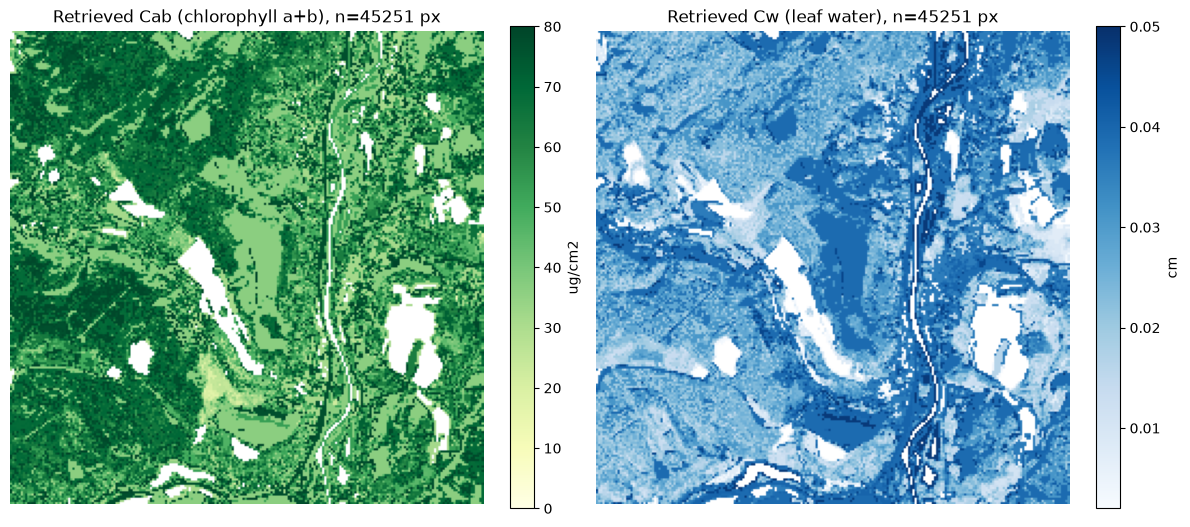

In [6]:
CROP_SIZE = 220
STRIDE = 40

n_rows, n_cols = vegetation_mask.shape
best_window, best_density = None, -1.0
for r0 in range(0, n_rows - CROP_SIZE, STRIDE):
    for c0 in range(0, n_cols - CROP_SIZE, STRIDE):
        window = vegetation_mask[r0:r0 + CROP_SIZE, c0:c0 + CROP_SIZE]
        density = window.mean()
        if density > best_density:
            best_density, best_window = density, (r0, c0)

r0, c0 = best_window
crop_mask = vegetation_mask[r0:r0 + CROP_SIZE, c0:c0 + CROP_SIZE]
crop_reflectance = reflectance[r0:r0 + CROP_SIZE, c0:c0 + CROP_SIZE, :]
print(f"Chosen crop: rows {r0}:{r0+CROP_SIZE}, cols {c0}:{c0+CROP_SIZE}, "
      f"vegetation density {best_density:.1%}, {crop_mask.sum()} pixels to invert")

crop_rows, crop_cols = np.where(crop_mask)
crop_spectra = crop_reflectance[crop_rows, crop_cols, :]

CHUNK = 8000
retrieved_chunks = []
for start in range(0, len(crop_spectra), CHUNK):
    chunk = crop_spectra[start:start + CHUNK]
    retrieved_chunks.append(pi.invert_lut_batch(chunk, reference_lut, wavelength_mask=valid_bands))
crop_retrieved = np.concatenate(retrieved_chunks, axis=0)

cab_idx = param_names.index("Cab")
cw_idx = param_names.index("Cw")

cab_map = np.full(crop_mask.shape, np.nan)
cw_map = np.full(crop_mask.shape, np.nan)
cab_map[crop_rows, crop_cols] = crop_retrieved[:, cab_idx]
cw_map[crop_rows, crop_cols] = crop_retrieved[:, cw_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
im0 = axes[0].imshow(cab_map, cmap="YlGn", vmin=0, vmax=80)
axes[0].set_title(f"Retrieved Cab (chlorophyll a+b), n={len(crop_rows)} px")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, label="ug/cm2")
im1 = axes[1].imshow(cw_map, cmap="Blues", vmin=0.002, vmax=0.05)
axes[1].set_title(f"Retrieved Cw (leaf water), n={len(crop_rows)} px")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, label="cm")
plt.tight_layout()
plt.savefig("../results/figures/03_hyperspectral_pigment_maps.png", dpi=150)
plt.show()

## Next steps

`04_multispectral_subset_comparison.ipynb` repeats this exact self-consistency test restricted to a 5-band UAV-like `wavelength_mask` and incremental SWIR additions, to quantify how much retrieval quality degrades — and how much SWIR recovers — relative to the hyperspectral baseline computed here.